# ¿A qué potencia se enciende el material?

Una lámina de material que genera calor por una reacción química. La velocidad de la
reacción crece **exponencialmente** con su propia temperatura, así que el material se
calienta, reacciona más rápido, se calienta más. Si la conducción hacia los bordes
alcanza a evacuar ese calor hay un estado estacionario; si no, hay **ignición**.

El modelo adimensional de Frank-Kamenetskii, con `u` la temperatura y `λ` la potencia
de la reacción:

$$ u'' + \lambda\, e^{u} = 0, \qquad u(0) = u(1) = 0 $$

Lo interesante: existe una **potencia crítica** `λ*` por encima de la cual el problema
**no tiene solución**. Ahí no es que el método falle: es que el material se enciende.

In [1]:
# Requisitos:  pip install numpy scipy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import LinearOperator, gmres

np.seterr(over="ignore")   # pasado λ* la temperatura desborda: eso ES la ignición

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Discretización

In [2]:
N = 200                                  # nodos interiores
h = 1.0 / (N + 1)
x = np.linspace(0, 1, N + 2)[1:-1]

LAMBDA_CRITICO = 3.513830719             # valor teórico para la lámina

def hacer_residuo(lam):
    def F(u):
        ub = np.zeros(N + 2)
        ub[1:-1] = u
        return -((ub[:-2] - 2*ub[1:-1] + ub[2:]) / h**2 + lam * np.exp(u)) * h**2
    return F

# el laplaciano discreto sirve de precondicionador y se factoriza una sola vez
_L = sp.diags([-np.ones(N-1), 2*np.ones(N), -np.ones(N-1)], [-1, 0, 1], format="csc")
_lu = spla.splu(_L)
M = LinearOperator((N, N), matvec=_lu.solve, dtype=float)

## Newton-Krylov con recorte del paso

In [3]:
def resolver(lam, u0, max_iter=40, tol=1e-10):
    F = hacer_residuo(lam)
    u = np.array(u0, float)
    Fu = F(u)
    n0 = np.linalg.norm(Fu)
    cuenta = {"Jv": 0}

    for it in range(max_iter):
        nF = np.linalg.norm(Fu)
        if nF <= tol * max(n0, 1.0):
            return True, u, it, cuenta["Jv"]
        if not np.isfinite(nF) or nF > 1e12:
            return False, u, it, cuenta["Jv"]

        def por_vector(v, u=u, Fu=Fu):
            cuenta["Jv"] += 1
            nv = np.linalg.norm(v)
            if nv == 0:
                return np.zeros_like(v)
            eps = np.sqrt(np.finfo(float).eps) * max(np.linalg.norm(u), 1.0) / nv
            return (F(u + eps*v) - Fu) / eps

        Jop = LinearOperator((N, N), matvec=por_vector, dtype=float)
        s, _ = gmres(Jop, -Fu, rtol=1e-4, atol=0.0, restart=30, maxiter=60, M=M)

        lam_paso = 1.0
        while lam_paso > 1e-10:
            ut = u + lam_paso * s
            Ft = F(ut)
            if np.linalg.norm(Ft) <= (1 - 1e-4 * lam_paso) * nF:
                break
            lam_paso *= 0.5
        else:
            return False, u, it, cuenta["Jv"]
        u, Fu = ut, Ft

    return False, u, max_iter, cuenta["Jv"]

## Subiendo la potencia poco a poco

Cada solución sirve de punto de partida para la potencia siguiente. Eso se llama
**continuación**, y es lo que permite llegar cerca del límite.

In [4]:
potencias = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.2, 3.35, 3.45, 3.50]

u = np.zeros(N)
curva, perfiles = [], []

print(f"{'λ':>6}  {'¿estacionario?':>15}  {'u máx':>8}  {'iters':>6}  {'J·v':>7}")
print("-" * 50)
for lam in potencias:
    ok, u_nuevo, its, jv = resolver(lam, u)
    if ok:
        u = u_nuevo
        curva.append((lam, u.max()))
        perfiles.append((lam, u.copy()))
        print(f"{lam:6.2f}  {'sí':>15}  {u.max():8.4f}  {its:6d}  {jv:7d}")
    else:
        print(f"{lam:6.2f}  {'NO':>15}  {'—':>8}  {its:6d}  {jv:7d}")

     λ   ¿estacionario?     u máx   iters      J·v
--------------------------------------------------
  0.50               sí    0.0660       2        6
  1.00               sí    0.1405       2        8
  1.50               sí    0.2265       3       15
  2.00               sí    0.3289       3       15
  2.50               sí    0.4580       3       15
  3.00               sí    0.6401       3       19
  3.20               sí    0.7465       3      865


  3.35               sí    0.8584       3     4760


  3.45               sí    0.9750       4     6338


  3.50               sí    1.0853       4     6524


## Pasarse del límite

In [5]:
for lam in [3.6, 4.0]:
    ok, _, its, jv = resolver(lam, u)
    estado = "estado estacionario" if ok else "IGNICIÓN (no hay solución)"
    print(f"λ = {lam:.1f}  ->  {estado}   [{its} iteraciones, {jv} productos J·v]")

print(f"\nλ* teórico = {LAMBDA_CRITICO:.6f}")
print(f"último λ con solución encontrada: {curva[-1][0]}")

λ = 3.6  ->  IGNICIÓN (no hay solución)   [9 iteraciones, 17381 productos J·v]


λ = 4.0  ->  IGNICIÓN (no hay solución)   [18 iteraciones, 33757 productos J·v]

λ* teórico = 3.513831
último λ con solución encontrada: 3.5


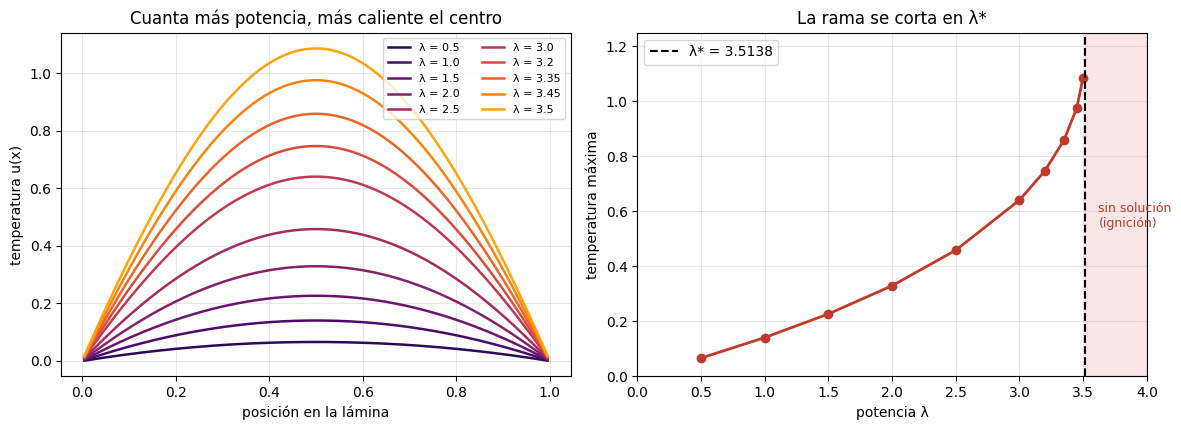

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))

colores = plt.cm.inferno(np.linspace(0.15, 0.8, len(perfiles)))
for (lam, perfil), c in zip(perfiles, colores):
    a1.plot(x, perfil, color=c, lw=1.8, label=f"λ = {lam}")
a1.set_xlabel("posición en la lámina")
a1.set_ylabel("temperatura u(x)")
a1.set_title("Cuanta más potencia, más caliente el centro")
a1.grid(alpha=.3)
a1.legend(fontsize=8, ncol=2)

lams = [c[0] for c in curva]
umax = [c[1] for c in curva]
a2.plot(lams, umax, "o-", color="#c0392b", ms=6, lw=2)
a2.axvline(LAMBDA_CRITICO, color="black", ls="--", lw=1.5,
           label=f"λ* = {LAMBDA_CRITICO:.4f}")
a2.fill_betweenx([0, max(umax)*1.15], LAMBDA_CRITICO, 4.0,
                 color="#c0392b", alpha=0.12)
a2.text(3.62, max(umax)*0.5, "sin solución\n(ignición)", fontsize=9, color="#c0392b")
a2.set_xlim(0, 4.0)
a2.set_ylim(0, max(umax)*1.15)
a2.set_xlabel("potencia λ")
a2.set_ylabel("temperatura máxima")
a2.set_title("La rama se corta en λ*")
a2.grid(alpha=.3); a2.legend()

plt.tight_layout(); plt.show()

Dos cosas para notar en la tabla de arriba.

La primera es que la columna de **productos `J·v` explota** al acercarse a `λ*`: pasa
de unas decenas a varios miles. No es casualidad — en el punto crítico el Jacobiano se
vuelve singular, y el trabajo que cuesta resolver el sistema lineal es el aviso de que
uno está llegando al límite.

La segunda es que para `λ > λ*` el método no converge, y hace bien: no hay ningún
estado estacionario que encontrar. El material se enciende.